<a href="https://colab.research.google.com/github/Saurabhrai08/Sentiment_analysis_UGC_ACT_2026/blob/main/bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets torch scikit-learn

In [2]:
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

In [3]:
df = pd.read_csv("/content/ugc_sentiment_Cleaned_dataset.csv")

print("Columns:", df.columns)
print("Total Rows:", len(df))

df.head()

Columns: Index(['Source', 'URL', 'Original_Text', 'Translated_Text', 'Cleaned_Text',
       'Language', 'Sentiment'],
      dtype='object')
Total Rows: 6969


,Source,URL,Original_Text,Translated_Text,Cleaned_Text,Language,Sentiment
0,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,Copyright © 2026 Regional College Of Management,Copyright © 2026 Regional College Of Management,copyright regional college of management,en,Neutral
1,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,Home > blogs > ugc act 2026 > What is UGC Act ...,Home > blogs > ugc act 2026 > What is UGC Act ...,home blogs ugc act what is ugc act,en,Neutral
2,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,"New UGC Rules, Bill, Guidelines & Why It Matters","New UGC Rules, Bill, Guidelines & Why It Matters",new ugc rules bill guidelines why it matters,en,Neutral
3,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,The UGC Act 2026 has become one of the most di...,The UGC Act 2026 has become one of the most di...,the ugc act has become one of the most discuss...,en,Negative
4,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,"But what is UGC Act 2026, and why are the new ...","But what is UGC Act 2026, and why are the new ...",but what is ugc act and why are the new ugc ru...,en,Positive


In [4]:
# Detect Text column
if 'Cleaned_Text' in df.columns:
    df['Text'] = df['Cleaned_Text']
elif 'Text' in df.columns:
    df['Text'] = df['Text']
else:
    raise ValueError("No text column found!")

# Detect Sentiment column
possible_labels = ['Sentiment', 'sentiment', 'label', 'Label']
label_col = None

for col in possible_labels:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("No sentiment label column found!")

df['Sentiment'] = df[label_col]

df.head()

,Source,URL,Original_Text,Translated_Text,Cleaned_Text,Language,Sentiment,Text
0,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,Copyright © 2026 Regional College Of Management,Copyright © 2026 Regional College Of Management,copyright regional college of management,en,Neutral,copyright regional college of management
1,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,Home > blogs > ugc act 2026 > What is UGC Act ...,Home > blogs > ugc act 2026 > What is UGC Act ...,home blogs ugc act what is ugc act,en,Neutral,home blogs ugc act what is ugc act
2,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,"New UGC Rules, Bill, Guidelines & Why It Matters","New UGC Rules, Bill, Guidelines & Why It Matters",new ugc rules bill guidelines why it matters,en,Neutral,new ugc rules bill guidelines why it matters
3,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,The UGC Act 2026 has become one of the most di...,The UGC Act 2026 has become one of the most di...,the ugc act has become one of the most discuss...,en,Negative,the ugc act has become one of the most discuss...
4,rcm.ac.in,https://rcm.ac.in/what-is-ugc-act-2026/,"But what is UGC Act 2026, and why are the new ...","But what is UGC Act 2026, and why are the new ...",but what is ugc act and why are the new ugc ru...,en,Positive,but what is ugc act and why are the new ugc ru...


In [5]:
df = df[['Text', 'Sentiment']]
df.dropna(inplace=True)
df = df[df['Text'].str.strip() != ""]

print("Cleaned Data Size:", len(df))
df.head()

Cleaned Data Size: 6969


,Text,Sentiment
0,copyright regional college of management,Neutral
1,home blogs ugc act what is ugc act,Neutral
2,new ugc rules bill guidelines why it matters,Neutral
3,the ugc act has become one of the most discuss...,Negative
4,but what is ugc act and why are the new ugc ru...,Positive


In [6]:
print("Before Balancing:")
print(df['Sentiment'].value_counts())

Before Balancing:
Sentiment
Positive    2390
Neutral     2312
Negative    2267
Name: count, dtype: int64


In [7]:
min_count = df['Sentiment'].value_counts().min()

df = df.groupby('Sentiment').apply(lambda x: x.sample(min_count)).reset_index(drop=True)

print("After Balancing:")
print(df['Sentiment'].value_counts())

After Balancing:
Sentiment
Negative    2267
Neutral     2267
Positive    2267
Name: count, dtype: int64


/tmp/ipykernel_11117/3549827508.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Sentiment').apply(lambda x: x.sample(min_count)).reset_index(drop=True)


In [8]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("Label Mapping:")
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

Label Mapping:
{'Negative': 0, 'Neutral': 1, 'Positive': 2}


In [9]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)

In [12]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label_encoder.classes_)
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [15]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics   # this still works ✅
)

In [17]:
trainer.train()

Step,Training Loss
500,0.828546
1000,0.456842
1500,0.339078
2000,0.208725
2500,0.109977


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2720, training_loss=0.36428101834128884, metrics={'train_runtime': 1242.373, 'train_samples_per_second': 17.515, 'train_steps_per_second': 2.189, 'total_flos': 2862673984880640.0, 'train_loss': 0.36428101834128884, 'epoch': 4.0})

In [18]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("Classification Report:\n")
print(classification_report(test_labels, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       458
           1       0.93      0.85      0.88       455
           2       0.87      0.89      0.88       448

    accuracy                           0.88      1361
   macro avg       0.88      0.88      0.88      1361
weighted avg       0.88      0.88      0.88      1361



In [19]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(test_labels, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8802351212343865


In [20]:




















trainer.save_model("bert-sentiment-model")
tokenizer.save_pretrained("bert-sentiment-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert-sentiment-model/tokenizer_config.json',
 'bert-sentiment-model/tokenizer.json')

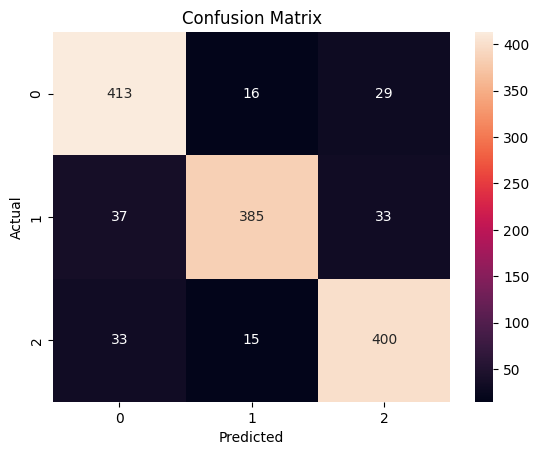

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
import shutil

shutil.make_archive("bert-sentiment-model", 'zip', "bert-sentiment-model")

'/content/bert-sentiment-model.zip'

In [24]:
from google.colab import files
files.download("bert-sentiment-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [28]:
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>